# AlphaPulse Investment Risk Monitor Exploration

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_stock_data
from src.returns_calculator import calculate_returns
from src.correlation import plot_correlation
from src.volatility import rolling_volatility
from src.var_model import calculate_var
from src.monte_carlo import monte_carlo_simulation

In [2]:
# Load stock data
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
data = load_stock_data(stocks)
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,72.400513,94.900497,67.873032,152.158386,28.684000
2020-01-03,71.696632,93.748497,67.517960,150.263733,29.534000
2020-01-06,72.267929,95.143997,69.317596,150.652145,30.102667
2020-01-07,71.928055,95.343002,69.183685,149.278564,31.270666
2020-01-08,73.085114,94.598503,69.676132,151.656311,32.809334


In [3]:
# Calculate returns
returns = calculate_returns(data)
returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452,0.029633
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.019255
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.038801
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.049205
2020-01-09,0.021241,0.004799,0.010498,0.012493,-0.021945


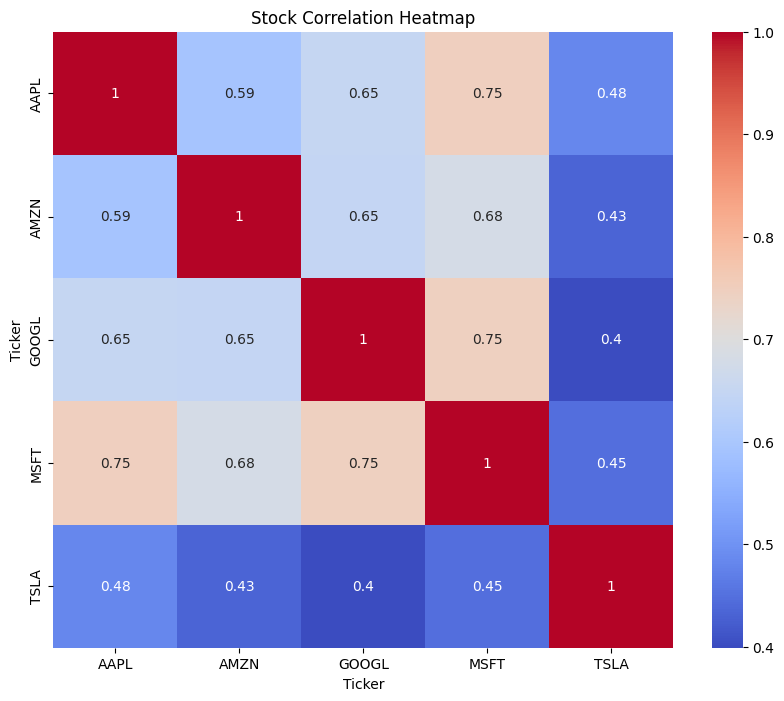

In [4]:
# Plot correlation
plot_correlation(returns)

In [5]:
# Calculate rolling volatility
vol = rolling_volatility(returns)
vol.tail()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2024-12-24,0.008616,0.019060,0.022640,0.012107,0.039291
2024-12-26,0.008575,0.019149,0.022651,0.011977,0.037305
2024-12-27,0.009190,0.018945,0.022635,0.012422,0.038926
2024-12-30,0.009546,0.018914,0.022374,0.012654,0.037692
2024-12-31,0.009181,0.017161,0.022177,0.011621,0.038288


In [6]:
# Calculate VaR
var_value = calculate_var(returns)
print(f"VaR at 95% confidence: {var_value}")

VaR at 95% confidence: -0.032193178978929086


In [7]:
# Monte Carlo simulation
sim_results = monte_carlo_simulation(returns, simulations=100, days=252)
print(f"Simulations completed: {len(sim_results)}")
print(f"Sample: Return {sim_results[0][0]:.4f}, Volatility {sim_results[0][1]:.4f}")

Simulations completed: 100
Sample: Return 0.2968, Volatility 0.2898
